In [1]:
import sys
import tensorflow as tf
import keras

print(sys.version)
print(tf.__version__)
print(keras.__version__)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
2.20.0
3.12.3


In [2]:
%pip install tensorflow==2.20.0 keras==3.12.3 numpy pandas matplotlib seaborn scikit-learn joblib plotly tqdm ipykernel

In [3]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [4]:
import sys
print(sys.executable)

c:\Users\aayus\Downloads\AI_BMS_Dashboard\AI_BMS_Dashboard\venv\Scripts\python.exe


In [5]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [6]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)


In [7]:
df = pd.read_csv('data/battery_50k.csv')

print(df.shape)

df.head()

(50000, 13)


,Voltage_measured,Current_measured,Temperature_measured,Time,Battery,Current_charge,Voltage_charge,Cycle,Capacity,SOC,SOH,SOC_Bin,Operation_Type
0,0.501830,0.803946,0.623082,0.428490,4219,0.807973,0.878709,0.331506,0.668494,50.182997,87.925035,"(50.0, 60.0]",Charging
1,0.499155,0.775716,0.021549,0.587129,422,0.779767,0.855208,0.580007,0.419993,49.915450,78.873545,"(40.0, 50.0]",Charging
2,0.474576,0.995744,0.350174,0.037249,2446,0.998837,0.941048,0.325230,0.674770,47.457579,88.153665,"(40.0, 50.0]",Charging
3,0.500438,0.779549,0.328825,0.434914,5086,0.782724,0.859391,0.145976,0.854024,50.043824,94.682895,"(50.0, 60.0]",Charging
4,0.500210,0.755811,0.635461,0.734805,2380,0.759302,0.845449,0.531661,0.468339,50.021009,80.634495,"(50.0, 60.0]",Charging


In [8]:
print(df.isnull().sum())

Voltage_measured        0
Current_measured        0
Temperature_measured    0
Time                    0
Battery                 0
Current_charge          0
Voltage_charge          0
Cycle                   0
Capacity                0
SOC                     0
SOH                     0
SOC_Bin                 0
Operation_Type          0
dtype: int64


In [9]:
X = df[
    [
        'Voltage_measured',
        'Current_measured',
        'Temperature_measured',
        'Current_charge',
        'Voltage_charge',
        'Cycle'
    ]
]

y = df[
    [
        'SOC',
        'SOH'
    ]
]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
model = Sequential()

model.add(
    Dense(
        128,
        activation='relu',
        input_shape=(6,)
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(
        32,
        activation='relu'
    )
)

model.add(
    Dense(
        2
    )
)

c:\Users\aayus\Downloads\AI_BMS_Dashboard\AI_BMS_Dashboard\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
print("Scaler Mean:")
print(scaler.mean_)

print()

print("Scaler Std:")
print(scaler.scale_)

print()

print(X_train.head())

print()

print(X_train_scaled[:5])

Scaler Mean:
[0.48185686 0.79185484 0.2893824  0.83380412 0.81218457 0.50137185]

Scaler Std:
[0.05701633 0.1547504  0.18431186 0.09046873 0.24086458 0.28886404]

       Voltage_measured  Current_measured  Temperature_measured  \
39087          0.402001          0.079905              0.775489   
30893          0.499659          0.996341              0.371443   
45278          0.499456          0.766788              0.038052   
16398          0.500156          0.751394              0.312603   
13653          0.393680          0.745794              0.411823   

       Current_charge  Voltage_charge     Cycle  
39087        0.834148        0.810381  0.945964  
30893        1.000000        0.983071  0.405428  
45278        0.770714        0.850229  0.493862  
16398        0.754983        0.843258  0.858722  
13653        0.834148        0.810381  0.461014  

[[-1.40058745e+00 -4.60063427e+00  2.63741085e+00  3.79767045e-03
  -7.48626398e-03  1.53910420e+00]
 [ 3.12228213e-01  1.32139057e+0

In [14]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,298 (44.13 KB)

 Trainable params: 11,298 (44.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [17]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 571.4954 - mae: 14.5392 - val_loss: 29.9346 - val_mae: 3.5971
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56.6449 - mae: 5.6959 - val_loss: 6.5006 - val_mae: 1.7213
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 40.5736 - mae: 4.8958 - val_loss: 2.6021 - val_mae: 1.1268
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 35.7337 - mae: 4.6112 - val_loss: 1.9716 - val_mae: 1.0943
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32.3541 - mae: 4.3719 - val_loss: 1.9506 - val_mae: 1.0745
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29.0950 - mae: 4.1413 - val_loss: 8.3497 - val_mae: 2.7743
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23.6698 - mae: 3.7062 - val_loss: 10.5212 - val_mae: 3.1420
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18.5430 - mae: 3.2432 - val_loss: 22.3528 - val_mae: 4.6455
Epoch 9/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [18]:
loss, mae = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test MAE:", mae)

Test Loss: 2.0401253700256348
Test MAE: 1.0869548320770264


In [19]:
y_pred = model.predict(X_test_scaled)

soc_pred = y_pred[:,0]
soh_pred = y_pred[:,1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step


In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# SOC
soc_mae = mean_absolute_error(y_test['SOC'], soc_pred)
soc_rmse = np.sqrt(mean_squared_error(y_test['SOC'], soc_pred))
soc_r2 = r2_score(y_test['SOC'], soc_pred)

# SOH
soh_mae = mean_absolute_error(y_test['SOH'], soh_pred)
soh_rmse = np.sqrt(mean_squared_error(y_test['SOH'], soh_pred))
soh_r2 = r2_score(y_test['SOH'], soh_pred)

print("SOC MAE :", soc_mae)
print("SOC RMSE:", soc_rmse)
print("SOC R2  :", soc_r2)

print()

print("SOH MAE :", soh_mae)
print("SOH RMSE:", soh_rmse)
print("SOH R2  :", soh_r2)

SOC MAE : 1.2175086675812214
SOC RMSE: 1.4943556842675538
SOC R2  : 0.9345696103394577

SOH MAE : 0.9564008790178227
SOH RMSE: 1.359100198450752
SOH R2  : 0.9831932772696328


In [21]:
soc_true = y_test['SOC']
soh_true = y_test['SOH']

soc_pred = y_pred[:, 0]
soh_pred = y_pred[:, 1]

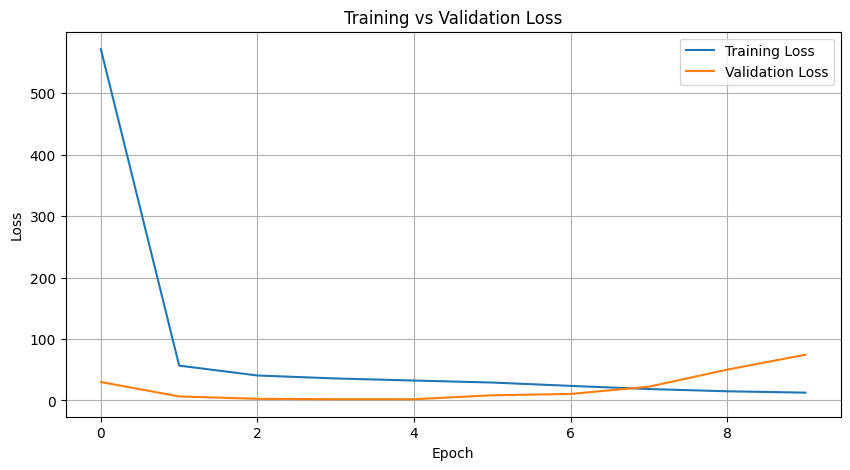

In [22]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

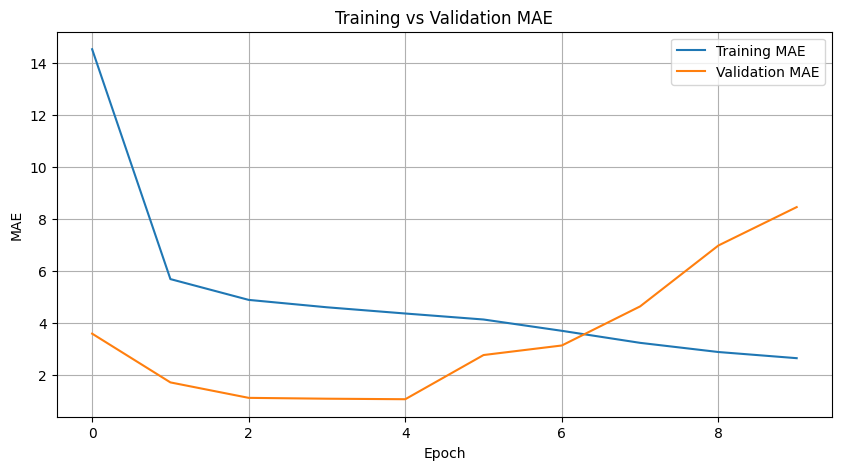

In [23]:
plt.figure(figsize=(10,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)

plt.show()

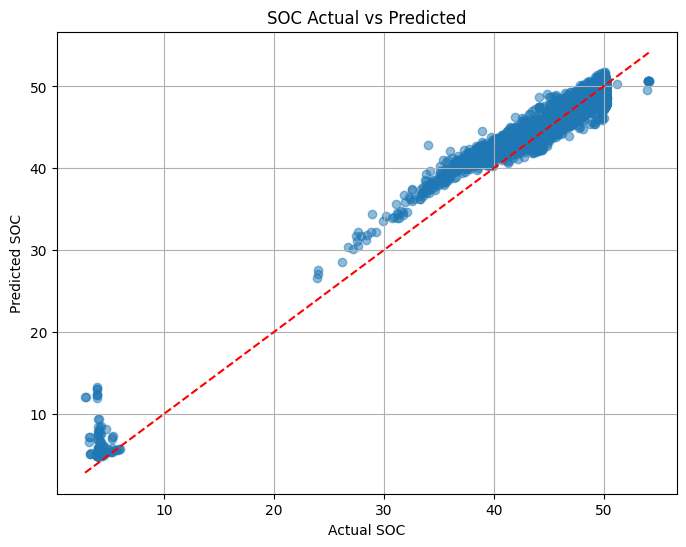

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    soc_true,
    soc_pred,
    alpha=0.5
)

plt.plot(
    [soc_true.min(), soc_true.max()],
    [soc_true.min(), soc_true.max()],
    'r--'
)

plt.xlabel("Actual SOC")
plt.ylabel("Predicted SOC")
plt.title("SOC Actual vs Predicted")

plt.grid(True)

plt.show()

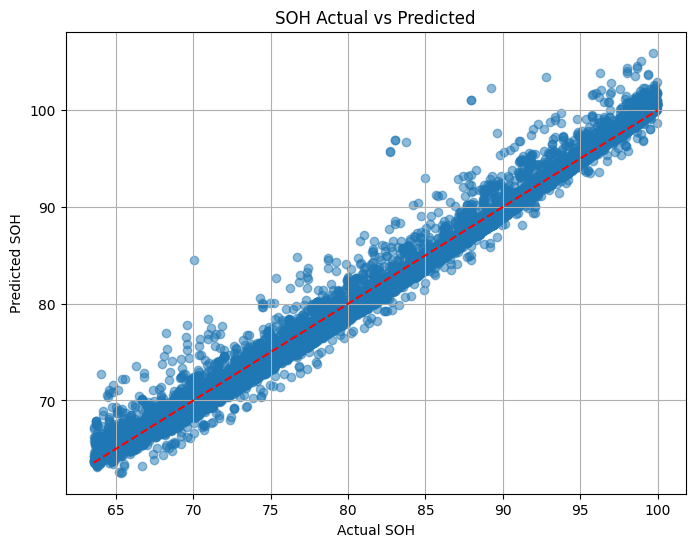

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    soh_true,
    soh_pred,
    alpha=0.5
)

plt.plot(
    [soh_true.min(), soh_true.max()],
    [soh_true.min(), soh_true.max()],
    'r--'
)

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("SOH Actual vs Predicted")

plt.grid(True)

plt.show()

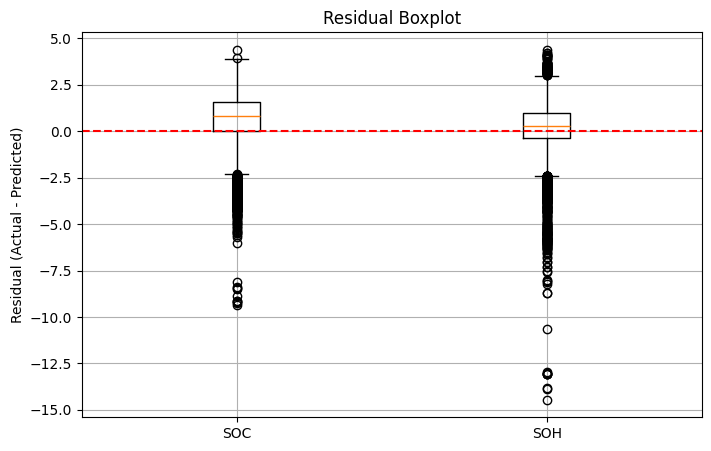

In [26]:
import matplotlib.pyplot as plt

# Residuals
soc_residual = y_test['SOC'] - y_pred[:,0]
soh_residual = y_test['SOH'] - y_pred[:,1]

plt.figure(figsize=(8,5))

plt.boxplot(
    [soc_residual, soh_residual],
    tick_labels=['SOC','SOH']
)

plt.axhline(0,color='red',linestyle='--')

plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Boxplot")

plt.grid(True)

plt.show()

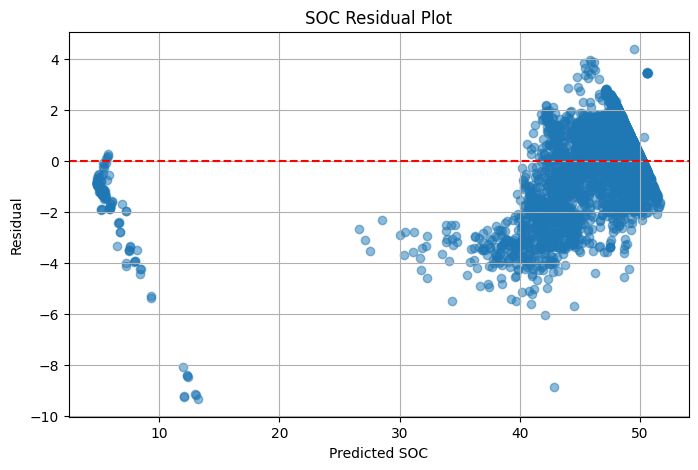

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred[:,0],
    soc_residual,
    alpha=0.5
)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Predicted SOC")
plt.ylabel("Residual")

plt.title("SOC Residual Plot")

plt.grid(True)

plt.show()

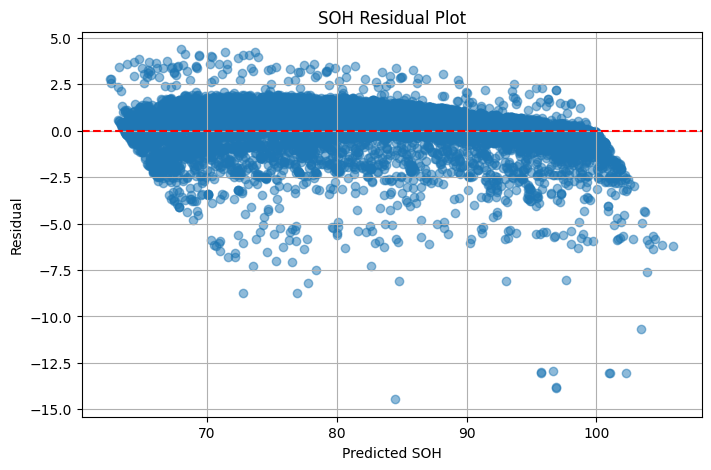

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred[:,1],
    soh_residual,
    alpha=0.5
)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Predicted SOH")
plt.ylabel("Residual")

plt.title("SOH Residual Plot")

plt.grid(True)

plt.show()

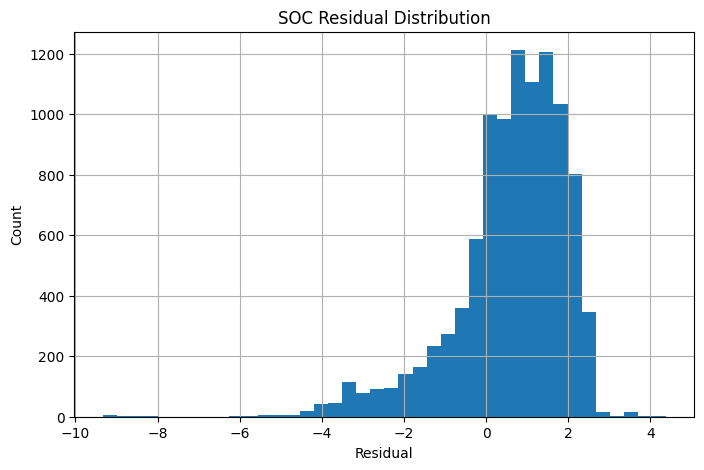

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    soc_residual,
    bins=40
)

plt.xlabel("Residual")

plt.ylabel("Count")

plt.title("SOC Residual Distribution")

plt.grid(True)

plt.show()

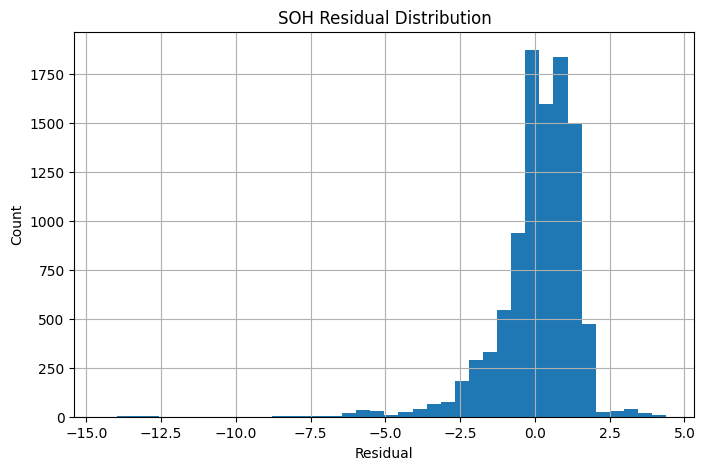

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    soh_residual,
    bins=40
)

plt.xlabel("Residual")

plt.ylabel("Count")

plt.title("SOH Residual Distribution")

plt.grid(True)

plt.show()

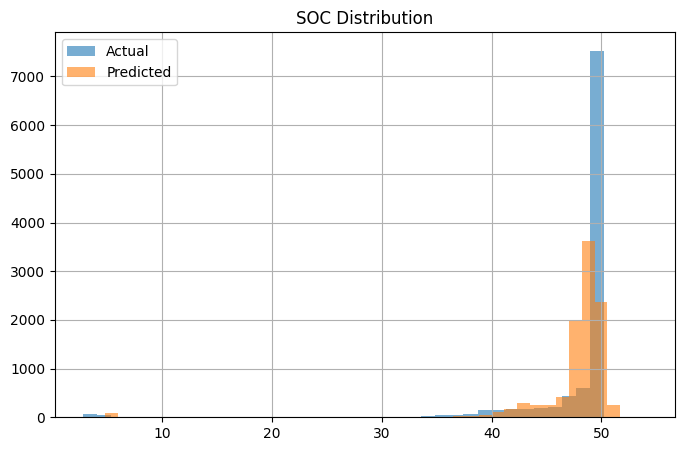

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test['SOC'],
    bins=40,
    alpha=0.6,
    label='Actual'
)

plt.hist(
    y_pred[:,0],
    bins=40,
    alpha=0.6,
    label='Predicted'
)

plt.legend()

plt.title("SOC Distribution")

plt.grid(True)

plt.show()

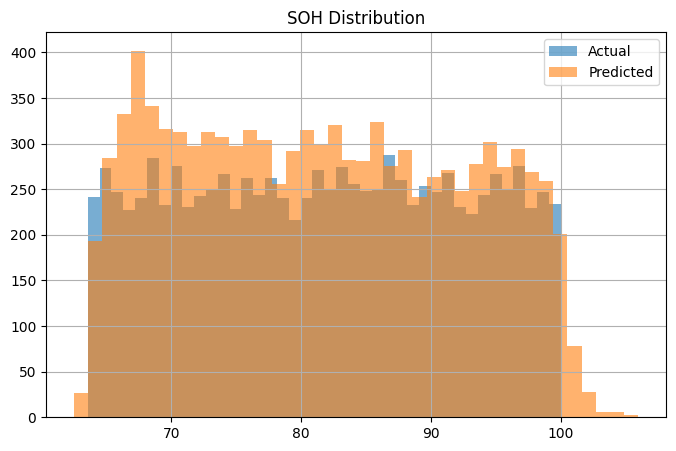

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test['SOH'],
    bins=40,
    alpha=0.6,
    label='Actual'
)

plt.hist(
    y_pred[:,1],
    bins=40,
    alpha=0.6,
    label='Predicted'
)

plt.legend()

plt.title("SOH Distribution")

plt.grid(True)

plt.show()

In [33]:
# Save ANN Model
model.save("models/ann_soc_soh_model.keras")

print("✅ ANN Model Saved Successfully!")

✅ ANN Model Saved Successfully!


In [34]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(scaler, "models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [35]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "models/feature_columns.pkl")

['models/feature_columns.pkl']

In [36]:
import pandas as pd

# Convert training history to DataFrame
history_df = pd.DataFrame(history.history)

# Save to CSV
history_df.to_csv("data/history.csv", index=False)

print("✅ history.csv saved successfully")

✅ history.csv saved successfully


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
soc_mae = mean_absolute_error(y_test['SOC'], y_pred[:,0])
soc_rmse = np.sqrt(mean_squared_error(y_test['SOC'], y_pred[:,0]))
soc_r2 = r2_score(y_test['SOC'], y_pred[:,0])

soh_mae = mean_absolute_error(y_test['SOH'], y_pred[:,1])
soh_rmse = np.sqrt(mean_squared_error(y_test['SOH'], y_pred[:,1]))
soh_r2 = r2_score(y_test['SOH'], y_pred[:,1])

# Save metrics
with open("metrics.txt", "w") as f:

    f.write("========== ANN MODEL PERFORMANCE ==========\n\n")

    f.write("SOC Prediction\n")
    f.write(f"MAE  : {soc_mae:.4f}\n")
    f.write(f"RMSE : {soc_rmse:.4f}\n")
    f.write(f"R2   : {soc_r2:.4f}\n\n")

    f.write("SOH Prediction\n")
    f.write(f"MAE  : {soh_mae:.4f}\n")
    f.write(f"RMSE : {soh_rmse:.4f}\n")
    f.write(f"R2   : {soh_r2:.4f}\n")

print("✅ metrics.txt saved successfully")

✅ metrics.txt saved successfully


In [38]:
import os

print("Saved Files:\n")

for file in os.listdir():
    if file.endswith((".keras", ".pkl", ".csv", ".txt")):
        print(file)

Saved Files:

metrics.txt
requirements.txt


In [39]:
print(locals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'sys', 'tf', 'keras', '_i2', '_exit_code', '_i3', '_i4', '_i5', 'pd', 'np', 'random', 'train_test_split', 'StandardScaler', 'Sequential', 'Dense', 'Dropout', 'EarlyStopping', 'mean_absolute_error', 'mean_squared_error', 'r2_score', 'plt', '_i6', '_i7', 'df', '_7', '_i8', '_i9', 'X', 'y', '_i10', 'X_train', 'X_test', 'y_train', 'y_test', '_i11', 'scaler', 'X_train_scaled', 'X_test_scaled', '_i12', 'model', '_i13', '_i14', '_i15', '_i16', 'early_stop', '_i17', 'history', '_i18', 'loss', 'mae', '_i19', 'y_pred', 'soc_pred', 'soh_pred', '_i20', 'soc_mae', 'soc_rmse', 'soc_r2', 'soh_mae', 'soh_rmse', 'soh_r2', '_i21', 'soc_true', 'soh_true', '_i22', '_i23', '_i24', '_i25', '_i26', 'soc_residual', 'soh_residual', '_i27', '_i28', '_i29', '_i30', '_i3

In [40]:
print(df[
    [
        "Voltage_measured",
        "Current_measured",
        "Temperature_measured",
        "Current_charge",
        "Voltage_charge",
        "Cycle"
    ]
].describe())

       Voltage_measured  Current_measured  Temperature_measured  \
count      50000.000000      50000.000000          50000.000000   
mean           0.481746          0.791771              0.289088   
std            0.057301          0.154786              0.184399   
min            0.027837          0.078834              0.002024   
25%            0.490759          0.751958              0.068558   
50%            0.500118          0.770034              0.325744   
75%            0.501127          0.870667              0.368942   
max            0.541219          0.998342              0.908928   

       Current_charge  Voltage_charge         Cycle  
count    50000.000000    50000.000000  50000.000000  
mean         0.833773        0.811173      0.501259  
std          0.090455        0.242423      0.288658  
min          0.116279        0.000000      0.000002  
25%          0.761130        0.844453      0.251354  
50%          0.795166        0.856005      0.502060  
75%          0.875

In [41]:
print(df["SOH"].min())
print(df["SOH"].max())

63.575770000000006
99.99993
